# 🧑‍🏫 Aula 5 — Redes Neurais: MLP e CNN para Defeitos Têxteis

**UC:** Machine Learning | **Data:** 13/05/2026 | **Duração:** 3 horas

---

## 🎯 Objetivos desta Aula

Nas aulas anteriores usamos **árvores, SVMs e KNN** para classificar qualidade; **regressores lineares e XGBoost** para prever produção; e **detectores não supervisionados** para anomalias. Agora entramos no mundo das **redes neurais artificiais** — o motor por trás da maioria dos sistemas modernos de IA (visão computacional, NLP, LLMs).

Vamos construir **dois tipos de rede** aplicados a dois problemas reais da indústria têxtil:

1. 🧮 **MLP (Multi-Layer Perceptron)** — para **dados tabulares** de qualidade do tecido (reaproveitando o dataset da Aula 1)
2. 🖼️ **CNN (Convolutional Neural Network)** — para **imagens** de defeitos em tecido (6 classes: `good`, `color`, `cut`, `hole`, `thread`, `metal_contamination`)

### O que você vai aprender nesta aula:

1. 🧠 **Neurônio artificial** — o que é uma camada `Dense`, função de ativação, pesos e vieses
2. 🏗️ **Arquitetura MLP** — camadas empilhadas (`Dense → ReLU → Dropout → ...`)
3. 📸 **Arquitetura CNN** — convolução, `MaxPooling`, extração hierárquica de features
4. 🎛️ **Callbacks essenciais:** `EarlyStopping`, `ReduceLROnPlateau`, `ModelCheckpoint`
5. 📊 **MLflow autolog** — tracking automático de epochs, loss e accuracy do Keras
6. ⚖️ **Comparar MLP (tabular) com RandomForest (Aula 1)** — rede neural sempre vence?
7. 🎯 **Quando usar cada abordagem** na indústria

### Recapitulando a trilha:

| Aula | Paradigma | Algoritmos | Tipo de dado |
|---|---|---|---|
| 1 | Supervisionado (classif.) | RandomForest | Tabular |
| 2 | Supervisionado (classif.) | SVM, KNN, XGBoost, LightGBM | Tabular |
| 3 | Supervisionado (regressão) | Ridge, Lasso, SVR, XGBRegressor | Tabular |
| 4 | Não supervisionado | Isolation Forest, LOF, OCSVM, DBSCAN | Tabular |
| **5** | **Supervisionado (redes neurais)** | **MLP (tabular) + CNN (imagem)** | **Tabular E imagem** |

---

📦 **Datasets:**
- [Textile Fabric Quality Classification](https://www.kaggle.com/datasets/devendrakushwah08/textile-fabric-quality-classification-dataset) — reutilizamos o CSV **já limpo da Aula 1** (`../Aula_01/dataset_limpo.csv`) para o MLP
- [Textile Defect Detection](https://www.kaggle.com/datasets/belkhirnacim/textiledefectdetection) — 96.000 imagens 64×64 em tons de cinza, 6 classes de defeitos, para a CNN

> 💡 **Importante:** nesta aula vamos **subamostrar** o dataset de imagens para treinar rápido em sala (~1.000 imagens por classe). Na vida real, usaríamos o dataset completo com GPU.


## 1️⃣ Configuração do Ambiente e Importação de Bibliotecas

A grande novidade desta aula é o **TensorFlow / Keras** — a biblioteca mais popular para redes neurais. As demais já são velhas conhecidas.

| Biblioteca | Para que serve | Novidade? |
|---|---|---|
| `pandas` / `numpy` | Manipulação de dados | — |
| `matplotlib` / `seaborn` | Visualizações | — |
| `scikit-learn` | Split, scaler, métricas | — |
| `tensorflow` / `keras` | **Construir e treinar redes neurais** | ✅ **Novo** |
| `h5py` | Ler o arquivo `.h5` das imagens | ✅ Novo (utilitário) |
| `mlflow` | Tracking de experimentos (com **autolog** do Keras) | — |
| `joblib` | Salvar scaler / label encoder | — |
| `kagglehub` | Download do dataset de imagens | — |


In [2]:
# ============================================================
# INSTALAÇÃO DAS DEPENDÊNCIAS
# ============================================================
# Se já executou as aulas anteriores, quase tudo está instalado.
# TensorFlow e TensorBoard são as grandes novidades desta aula.

!pip install -q pandas numpy matplotlib seaborn scikit-learn mlflow joblib kagglehub h5py tensorflow tensorboard


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 81.9 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 90.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.6/887.6 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# ============================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

# --- Reduz verbosidade do TensorFlow ANTES de importá-lo ---
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # 0=tudo, 1=info, 2=warnings, 3=só errors
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"  # evita pequenas diferenças numéricas

# --- Manipulação de Dados ---
import pandas as pd
import numpy as np

# --- Visualização ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scikit-learn (split, scaler, métricas, RF para comparar) ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.ensemble import RandomForestClassifier

# *** TENSORFLOW / KERAS — a estrela desta aula ***
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
)

# --- Leitura dos arquivos .h5 de imagens ---
import h5py

# --- Tracking de experimentos ---
import mlflow

# --- Utilitários ---
import joblib
import warnings
warnings.filterwarnings("ignore")

# --- Configuração visual ---
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

# --- Reprodutibilidade ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

print("✅ Todas as bibliotecas foram importadas com sucesso!")
print(f"   🧠 TensorFlow: {tf.__version__}")
print(f"   📦 Keras:      {keras.__version__}")
print(f"   💻 GPU disponível? {'Sim' if tf.config.list_physical_devices('GPU') else 'Não (usando CPU)'}")


✅ Todas as bibliotecas foram importadas com sucesso!
   🧠 TensorFlow: 2.20.0
   📦 Keras:      3.13.2
   💻 GPU disponível? Não (usando CPU)


## 2️⃣ Configuração do MLflow e Pasta de Modelos

Mesmo padrão das aulas anteriores: criamos **um novo experimento** (`aula05_redes_neurais`) no `mlflow.db` compartilhado e a pasta `../modelos/aula05/` para salvar os modelos.

```
📁 MLflow Database (mlflow.db)
├── 🧪 aula01_qualidade_textil
├── 🧪 aula02_classificacao_tuning
├── 🧪 aula03_regressao_producao
├── 🧪 aula04_anomalias_teares
└── 🧪 aula05_redes_neurais          ← Nova nesta aula
```

> 🔎 **MLflow autolog:** para Keras, chamamos `mlflow.tensorflow.autolog()` **uma única vez**. A partir daí, todo `model.fit(...)` dentro de um `mlflow.start_run()` loga automaticamente: epochs, loss, accuracy, learning rate, arquitetura do modelo e o próprio modelo como artefato.


In [4]:
# ============================================================
# CONFIGURAÇÃO DO MLFLOW E DA PASTA DE MODELOS
# ============================================================

# --- Tracking ---
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("aula05_redes_neurais")

# --- Autolog específico para Keras/TensorFlow ---
# Loga automaticamente: params, metrics por epoch e o modelo.
# log_models=False porque nós mesmos vamos salvar o modelo final em .keras/.joblib.
mlflow.tensorflow.autolog(log_models=False, disable=False)

# --- Pasta de modelos (mesmo padrão das aulas anteriores) ---
MODELOS_DIR = os.path.join("..", "modelos", "aula05")
os.makedirs(MODELOS_DIR, exist_ok=True)

# Sufixos padronizados para versionamento
MLP_VERSION_SUFFIX = "qualidade_textil_v1"
CNN_VERSION_SUFFIX = "defeitos_textil_v1"

print("✅ MLflow configurado!")
print(f"   📁 Tracking URI: {mlflow.get_tracking_uri()}")
print(f"   🧪 Experimento:  aula05_redes_neurais")
print(f"   💾 Modelos em:   {MODELOS_DIR}/")
print(f"   🏷️  Sufixos:      {MLP_VERSION_SUFFIX}  |  {CNN_VERSION_SUFFIX}")


2026/05/14 00:10:22 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/14 00:10:22 INFO mlflow.store.db.utils: Updating database tables
2026/05/14 00:10:25 INFO mlflow.tracking.fluent: Experiment with name 'aula05_redes_neurais' does not exist. Creating a new experiment.


✅ MLflow configurado!
   📁 Tracking URI: sqlite:///../mlflow.db
   🧪 Experimento:  aula05_redes_neurais
   💾 Modelos em:   ../modelos/aula05/
   🏷️  Sufixos:      qualidade_textil_v1  |  defeitos_textil_v1


---

# 🅐 PARTE A — MLP para Dados Tabulares (Qualidade do Tecido)

## 3️⃣ Conceitos — O que é uma MLP?

Uma **MLP (Multi-Layer Perceptron)** é uma rede neural formada por **camadas totalmente conectadas** (cada neurônio de uma camada se liga a todos os da próxima):

```
  Entrada (15 features)
        │
        ▼
  ┌───────────────┐
  │ Dense(64) + ReLU │   ← extrai combinações não lineares
  └───────────────┘
        │
        ▼
  ┌───────────────┐
  │ Dropout(0.3)  │     ← desliga neurônios aleatórios p/ evitar overfitting
  └───────────────┘
        │
        ▼
  ┌───────────────┐
  │ Dense(32) + ReLU │
  └───────────────┘
        │
        ▼
  ┌───────────────────────┐
  │ Dense(3) + Softmax    │   ← saída: probabilidade por classe
  └───────────────────────┘
```

**Vocabulário essencial:**

| Termo | Significado |
|---|---|
| **Neurônio** | Pequena função `y = ativação(w·x + b)` — soma ponderada seguida de uma não-linearidade |
| **Camada Dense** | Conjunto de neurônios; "fully connected" |
| **Ativação ReLU** | `max(0, x)` — simples, rápida e evita o problema do gradiente desvanecente |
| **Softmax** | Transforma os valores da última camada em probabilidades que somam 1 |
| **Dropout** | Durante o treino, "desliga" aleatoriamente % dos neurônios → regulariza |
| **Epoch** | Uma passada completa por todo o dataset de treino |
| **Batch** | Quantas amostras processar antes de atualizar os pesos |
| **Loss** | Função que o treino tenta **minimizar** (aqui: `categorical_crossentropy`) |
| **Optimizer** | Algoritmo que atualiza os pesos (aqui: `Adam` — o mais popular) |

## 4️⃣ Carregamento do Dataset Tabular (da Aula 1)

Para economizar tempo e manter o foco em redes neurais, **reaproveitamos o CSV já limpo** que produzimos na Aula 1 (`../Aula_01/dataset_limpo.csv`) — ele já está sem nulos, sem duplicatas, com categóricas codificadas e o alvo `fabric_quality` como 0/1/2.


In [5]:
# # ============================================================
# # 4.1 — CARREGAMENTO DO DATASET TABULAR JÁ LIMPO (AULA 1)
# # ============================================================

# caminho_csv = os.path.join("..", "Aula_01", "dataset_limpo.csv")
# df_tab = pd.read_csv(caminho_csv)

# print(f"✅ Dataset tabular carregado de: {caminho_csv}")
# print(f"📊 Shape: {df_tab.shape[0]:,} linhas × {df_tab.shape[1]} colunas\n")
# print("Distribuição do alvo `fabric_quality` (0=Low, 1=Medium, 2=High):")
# print(df_tab["fabric_quality"].value_counts().sort_index())
# df_tab.head()


# ============================================================
# 4.1 — CARREGAMENTO DO DATASET TABULAR JÁ LIMPO (AULA 1)
# ============================================================
# Tenta primeiro o caminho local (VS Code / execução local).
# Se não encontrar (ex: Google Colab), baixa o dataset original
# do Kaggle e aplica o mesmo pré-processamento da Aula 1.

import kagglehub
from sklearn.preprocessing import LabelEncoder

caminho_csv_local = os.path.join("..", "Aula01", "dataset_limpo.csv")

if os.path.exists(caminho_csv_local):
    # ── Caminho local (VS Code, máquina pessoal) ──────────────
    df_tab = pd.read_csv(caminho_csv_local)
    print(f"✅ Dataset carregado do caminho local: {caminho_csv_local}")

else:
    # ── Fallback: Colab ou qualquer ambiente sem a Aula 1 ─────
    print("⚠️  dataset_limpo.csv não encontrado localmente.")
    print("    Baixando o dataset original do Kaggle e reprocessando...\n")

    # 1) Download via kagglehub
    ds_path = kagglehub.dataset_download(
        "devendrakushwah08/textile-fabric-quality-classification-dataset"
    )
    csv_files = [f for f in os.listdir(ds_path) if f.endswith(".csv")]
    df_tab = pd.read_csv(os.path.join(ds_path, csv_files[0]))
    print(f"   📥 CSV bruto carregado: {csv_files[0]}  →  {df_tab.shape}")

    # 2) Remove duplicatas
    df_tab = df_tab.drop_duplicates()

    # 3) Trata nulos
    for col in df_tab.select_dtypes(include=["int64", "float64"]).columns:
        df_tab[col] = df_tab[col].fillna(df_tab[col].median())
    for col in df_tab.select_dtypes(include=["object"]).columns:
        df_tab[col] = df_tab[col].fillna(df_tab[col].mode()[0])

    # 4) Remove colunas de ruído (mesmo critério da Aula 1)
    keywords_ruido = ["id", "batch", "roll", "warehouse", "operator",
                      "note", "inspector", "timestamp", "date", "shift"]
    TARGET = next((c for c in df_tab.columns if "quality" in c.lower()),
                  df_tab.columns[-1])
    colunas_ruido = [
        c for c in df_tab.columns
        if (any(kw in c.lower() for kw in keywords_ruido)
            or (df_tab[c].nunique() / len(df_tab) > 0.5
                and df_tab[c].dtype == "object"
                and c != TARGET))
    ]
    df_tab = df_tab.drop(columns=colunas_ruido)
    print(f"   🗑️  Colunas de ruído removidas: {colunas_ruido}")

    # 5) Label Encoding das categóricas (inclusive o target)
    for col in df_tab.select_dtypes(include=["object"]).columns:
        df_tab[col] = LabelEncoder().fit_transform(df_tab[col])

    # Garante que a coluna alvo se chama "fabric_quality"
    if TARGET != "fabric_quality":
        df_tab = df_tab.rename(columns={TARGET: "fabric_quality"})

    print(f"   ✅ Pré-processamento concluído  →  {df_tab.shape}")

print(f"\n📊 Shape final: {df_tab.shape[0]:,} linhas × {df_tab.shape[1]} colunas")
print("Distribuição do alvo `fabric_quality` (0=Low, 1=Medium, 2=High):")
print(df_tab["fabric_quality"].value_counts().sort_index())
df_tab.head()

⚠️  dataset_limpo.csv não encontrado localmente.
    Baixando o dataset original do Kaggle e reprocessando...

Using Colab cache for faster access to the 'textile-fabric-quality-classification-dataset' dataset.
   📥 CSV bruto carregado: Industrial Fabric Quality Inspection Dataset.csv  →  (25750, 23)
   🗑️  Colunas de ruído removidas: ['batch_id', 'roll_number', 'warehouse_id', 'operator_name', 'inspection_shift', 'humidity_level', 'inspection_notes']
   ✅ Pré-processamento concluído  →  (25000, 16)

📊 Shape final: 25,000 linhas × 16 colunas
Distribuição do alvo `fabric_quality` (0=Low, 1=Medium, 2=High):
fabric_quality
0    8487
1    8274
2    8239
Name: count, dtype: int64


,thread_count,gsm,tensile_strength,shrinkage_percent,color_fastness,fabric_thickness,defect_count,elongation_percent,moisture_absorption,fabric_type,weave_type,finish_type,production_method,inspection_time_minutes,machine_temperature,fabric_quality
0,166.0,383.0,67.772683,7.744704,1,0.891865,11,31.299228,12.855777,2,2,2,0,45.957289,28.148868,1
1,273.0,107.0,106.508682,1.191272,1,0.872380,4,8.092515,7.224689,2,1,0,0,33.035982,42.033282,0
2,274.0,352.0,97.100410,5.274223,3,1.231906,3,24.134907,12.276679,3,1,1,0,35.768493,35.450923,0
3,213.0,200.0,17.876660,4.001214,1,0.320100,12,18.334479,14.732114,1,2,1,1,38.349274,23.459327,1
4,115.0,348.0,62.746013,2.529863,2,0.903725,14,6.396909,11.692512,0,0,1,1,44.339097,33.873426,1


### 4.2 — Preparação: Split, Padronização e One-Hot

**Passos obrigatórios ao treinar redes neurais com dados tabulares:**

1. **Separar X e y** e fazer `train_test_split` com estratificação.
2. **Padronizar X** com `StandardScaler` — redes neurais treinam muito melhor com entradas com média 0 e desvio 1 (evita que algumas features "dominem" o gradiente).
3. **One-hot encode o y** — para 3 classes, `[0, 1, 2]` vira `[[1,0,0], [0,1,0], [0,0,1]]`. Esse formato casa com `softmax` + `categorical_crossentropy`.
4. **Criar um conjunto de validação** — a MLP vai monitorar `val_loss` para parar cedo (`EarlyStopping`).


In [6]:
# ============================================================
# 4.2 — PREPARAÇÃO DOS DADOS TABULARES
# ============================================================

# --- 1) Separar X e y ---
feature_cols_mlp = [c for c in df_tab.columns if c != "fabric_quality"]
X_tab = df_tab[feature_cols_mlp].values.astype("float32")
y_tab = df_tab["fabric_quality"].values.astype("int64")

N_CLASSES_MLP = int(y_tab.max() + 1)   # 3 classes: 0/1/2
print(f"📐 X shape: {X_tab.shape}  |  y shape: {y_tab.shape}  |  n_classes: {N_CLASSES_MLP}")

# --- 2) Split train/test estratificado ---
X_train_tab, X_test_tab, y_train_tab, y_test_tab = train_test_split(
    X_tab, y_tab,
    test_size=0.2,
    stratify=y_tab,
    random_state=RANDOM_STATE,
)

# --- 3) Dentro do treino, separar ~15% como VALIDAÇÃO ---
#     (não usamos o test para validar — o test é intocável até o final)
X_train_tab, X_val_tab, y_train_tab, y_val_tab = train_test_split(
    X_train_tab, y_train_tab,
    test_size=0.15,
    stratify=y_train_tab,
    random_state=RANDOM_STATE,
)

# --- 4) Padronização (StandardScaler) ---
#     IMPORTANTE: fit só no TREINO; apenas transform em val e test.
scaler_mlp = StandardScaler()
X_train_tab_sc = scaler_mlp.fit_transform(X_train_tab)
X_val_tab_sc   = scaler_mlp.transform(X_val_tab)
X_test_tab_sc  = scaler_mlp.transform(X_test_tab)

# --- 5) One-hot encode do y ---
y_train_oh = keras.utils.to_categorical(y_train_tab, num_classes=N_CLASSES_MLP)
y_val_oh   = keras.utils.to_categorical(y_val_tab,   num_classes=N_CLASSES_MLP)
y_test_oh  = keras.utils.to_categorical(y_test_tab,  num_classes=N_CLASSES_MLP)

print(f"\n✅ Dados prontos para a MLP:")
print(f"   🏋️  Treino:    {X_train_tab_sc.shape}  |  y one-hot: {y_train_oh.shape}")
print(f"   🧪 Validação: {X_val_tab_sc.shape}   |  y one-hot: {y_val_oh.shape}")
print(f"   🧰 Teste:     {X_test_tab_sc.shape}   |  y one-hot: {y_test_oh.shape}")


📐 X shape: (25000, 15)  |  y shape: (25000,)  |  n_classes: 3

✅ Dados prontos para a MLP:
   🏋️  Treino:    (17000, 15)  |  y one-hot: (17000, 3)
   🧪 Validação: (3000, 15)   |  y one-hot: (3000, 3)
   🧰 Teste:     (5000, 15)   |  y one-hot: (5000, 3)


## 5️⃣ Construção da MLP com Keras

Usamos a API **Sequential** do Keras — o jeito mais simples de empilhar camadas. Lendo de cima para baixo:

1. **`Input(shape=(n_features,))`** — diz à rede quantas features esperar.
2. **`Dense(64, activation="relu")`** — 1ª camada oculta, extrai combinações não lineares.
3. **`Dropout(0.3)`** — regularização: em cada passo de treino, 30% dos neurônios são zerados aleatoriamente.
4. **`Dense(32, activation="relu")`** — 2ª camada oculta, mais compacta.
5. **`Dense(n_classes, activation="softmax")`** — saída com 3 probabilidades.

**Compilação:**
- `loss="categorical_crossentropy"` — padrão para classificação multiclasse com one-hot.
- `optimizer="adam"` — Adam com learning rate padrão (0.001).
- `metrics=["accuracy"]` — para acompanhar no console e no MLflow.


In [7]:
# ============================================================
# 5.1 — DEFINIÇÃO DA ARQUITETURA DA MLP
# ============================================================

def criar_mlp(n_features: int, n_classes: int) -> keras.Model:
    """Retorna uma MLP simples de 2 camadas ocultas com Dropout."""
    modelo = keras.Sequential(
        [
            layers.Input(shape=(n_features,), name="entrada"),
            layers.Dense(64, activation="relu", name="oculta_1"),
            layers.Dropout(0.3, name="dropout_1"),
            layers.Dense(32, activation="relu", name="oculta_2"),
            layers.Dropout(0.2, name="dropout_2"),
            layers.Dense(n_classes, activation="softmax", name="saida"),
        ],
        name="mlp_qualidade_textil",
    )
    modelo.compile(
        loss="categorical_crossentropy",
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        metrics=["accuracy"],
    )
    return modelo


# Instancia e mostra um resumo da arquitetura
mlp = criar_mlp(n_features=X_train_tab_sc.shape[1], n_classes=N_CLASSES_MLP)
mlp.summary()


Model: "mlp_qualidade_textil"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_1 (Dense)                │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida (Dense)                   │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,203 (12.51 KB)

 Trainable params: 3,203 (12.51 KB)

 Non-trainable params: 0 (0.00 B)

## 6️⃣ Treinamento da MLP com Callbacks + MLflow

**Callbacks** são "ganchos" que o Keras chama entre epochs. Usamos três clássicos:

| Callback | O que faz | Por quê? |
|---|---|---|
| **`EarlyStopping`** | Para o treino se `val_loss` não melhorar por N epochs | Evita overfitting e economiza tempo |
| **`ReduceLROnPlateau`** | Diminui o learning rate quando o treino "trava" | Permite ajuste fino no final |
| **`ModelCheckpoint`** | Salva o **melhor** modelo (menor `val_loss`) durante o treino | Garante que ficamos com o melhor snapshot |

O `mlflow.start_run()` envolve o treino para que o **autolog** registre tudo: epochs, loss, accuracy, etc.


In [8]:
# ============================================================
# 6.1 — TREINO DA MLP
# ============================================================

# Caminho temporário onde o ModelCheckpoint vai salvar o melhor modelo
melhor_mlp_path = os.path.join(MODELOS_DIR, f"_checkpoint_mlp_{MLP_VERSION_SUFFIX}.keras")

callbacks_mlp = [
    EarlyStopping(
        monitor="val_loss",
        patience=7,              # para se 7 epochs sem melhora
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,              # reduz LR pela metade
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=melhor_mlp_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=0,
    ),
]

# Treino envolto em run do MLflow (autolog registra tudo)
with mlflow.start_run(run_name="mlp_qualidade_textil_v1") as run_mlp:
    historico_mlp = mlp.fit(
        X_train_tab_sc, y_train_oh,
        validation_data=(X_val_tab_sc, y_val_oh),
        epochs=50,
        batch_size=128,
        callbacks=callbacks_mlp,
        verbose=2,
    )
    run_id_mlp = run_mlp.info.run_id

print(f"\n✅ MLP treinada. run_id = {run_id_mlp}")
print(f"📊 Epochs executadas: {len(historico_mlp.history['loss'])}")


Epoch 1/50


133/133 - 3s - 20ms/step - accuracy: 0.5501 - loss: 0.9197 - val_accuracy: 0.8513 - val_loss: 0.5078 - learning_rate: 0.0010
Epoch 2/50


133/133 - 1s - 5ms/step - accuracy: 0.8139 - loss: 0.4743 - val_accuracy: 0.9120 - val_loss: 0.3224 - learning_rate: 0.0010
Epoch 3/50


133/133 - 1s - 5ms/step - accuracy: 0.8599 - loss: 0.3891 - val_accuracy: 0.9203 - val_loss: 0.2930 - learning_rate: 0.0010
Epoch 4/50


133/133 - 1s - 5ms/step - accuracy: 0.8782 - loss: 0.3557 - val_accuracy: 0.9257 - val_loss: 0.2799 - learning_rate: 0.0010
Epoch 5/50


...

133/133 - 1s - 5ms/step - accuracy: 0.9505 - loss: 0.2041 - val_accuracy: 0.9480 - val_loss: 0.2088 - learning_rate: 5.0000e-04
Epoch 37/50


133/133 - 1s - 5ms/step - accuracy: 0.9502 - loss: 0.2057 - val_accuracy: 0.9490 - val_loss: 0.2087 - learning_rate: 5.0000e-04
Epoch 38/50


133/133 - 1s - 5ms/step - accuracy: 0.9499 - loss: 0.2022 - val_accuracy: 0.9473 - val_loss: 0.2086 - learning_rate: 5.0000e-04
Epoch 39/50


133/133 - 1s - 5ms/step - accuracy: 0.9495 - loss: 0.1988 - val_accuracy: 0.9490 - val_loss: 0.2082 - learning_rate: 5.0000e-04
Epoch 40/50


133/133 - 1s - 5ms/step - accuracy: 0.9500 - loss: 0.2047 - val_accuracy: 0.9500 - val_loss: 0.2065 - learning_rate: 5.0000e-04
Epoch 41/50
133/133 - 1s - 4ms/step - accuracy: 0.9525 - loss: 0.1972 - val_accuracy: 0.9473 - val_loss: 0.2085 - learning_rate: 5.0000e-04
Epoch 42/50
133/133 - 1s - 4ms/step - accuracy: 0.9514 - loss: 0.1975 - val_accuracy: 0.9487 - val_loss: 0.2087 - learning_rate: 5.0000e-04
Epoch 43/50

Epoch 43: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
133/133 - 1s - 4ms/step - accuracy: 0.9505 - loss: 0.2019 - val_accuracy: 0.9487 - val_loss: 0.2079 - learning_rate: 5.0000e-04
Epoch 44/50
133/133 - 1s - 4ms/step - accuracy: 0.9514 - loss: 0.1989 - val_accuracy: 0.9493 - val_loss: 0.2080 - learning_rate: 2.5000e-04
Epoch 45/50
133/133 - 1s - 4ms/step - accuracy: 0.9519 - loss: 0.1980 - val_accuracy: 0.9503 - val_loss: 0.2075 - learning_rate: 2.5000e-04
Epoch 46/50

Epoch 46: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
133/

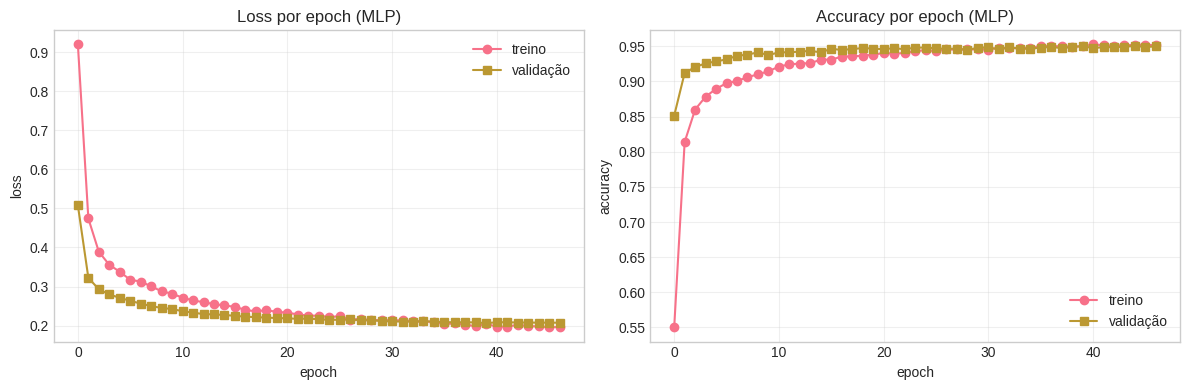

In [9]:
# ============================================================
# 6.2 — CURVAS DE TREINO (loss e accuracy por epoch)
# ============================================================
# Lemos diretamente o histórico retornado pelo .fit().

hist = historico_mlp.history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist["loss"],     label="treino",    marker="o")
axes[0].plot(hist["val_loss"], label="validação", marker="s")
axes[0].set_title("Loss por epoch (MLP)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist["accuracy"],     label="treino",    marker="o")
axes[1].plot(hist["val_accuracy"], label="validação", marker="s")
axes[1].set_title("Accuracy por epoch (MLP)")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 7️⃣ Avaliação da MLP no Teste + Comparação com RandomForest

Agora aplicamos o modelo no conjunto **de teste** (nunca visto durante o treino) e comparamos com um `RandomForestClassifier` rápido — mesmo tipo de modelo da Aula 1.

> 🧭 **Por que comparar?** Redes neurais nem sempre vencem em dados tabulares. Random Forests e XGBoost costumam ser **mais fáceis de ajustar** e com desempenho parecido (ou melhor) em tabelas pequenas/médias. Vamos verificar na prática.


In [10]:
# ============================================================
# 7.1 — AVALIAÇÃO DA MLP NO TESTE
# ============================================================

# predict devolve matriz de probabilidades (softmax) — pegamos argmax
y_pred_mlp_prob = mlp.predict(X_test_tab_sc, verbose=0)
y_pred_mlp      = y_pred_mlp_prob.argmax(axis=1)

acc_mlp = accuracy_score(y_test_tab, y_pred_mlp)
f1_mlp  = f1_score(y_test_tab, y_pred_mlp, average="macro")

print(f"🧠 MLP — Accuracy (teste): {acc_mlp:.4f}")
print(f"🧠 MLP — F1 macro (teste): {f1_mlp:.4f}\n")
print("📋 Classification report (MLP):")
print(classification_report(
    y_test_tab, y_pred_mlp,
    target_names=["Low (0)", "Medium (1)", "High (2)"],
))


🧠 MLP — Accuracy (teste): 0.9522
🧠 MLP — F1 macro (teste): 0.9522

📋 Classification report (MLP):
              precision    recall  f1-score   support

     Low (0)       0.96      0.96      0.96      1697
  Medium (1)       0.97      0.96      0.96      1655
    High (2)       0.93      0.94      0.94      1648

    accuracy                           0.95      5000
   macro avg       0.95      0.95      0.95      5000
weighted avg       0.95      0.95      0.95      5000



In [11]:
# ============================================================
# 7.2 — BASELINE: RandomForest rápido (referência da Aula 1)
# ============================================================

with mlflow.start_run(run_name="rf_baseline_comparacao", nested=False):
    rf_ref = RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    # RF aceita X não padronizado; usamos os arrays originais de treino (sem val)
    X_train_rf = np.vstack([X_train_tab, X_val_tab])
    y_train_rf = np.concatenate([y_train_tab, y_val_tab])
    rf_ref.fit(X_train_rf, y_train_rf)

    y_pred_rf = rf_ref.predict(X_test_tab)
    acc_rf = accuracy_score(y_test_tab, y_pred_rf)
    f1_rf  = f1_score(y_test_tab, y_pred_rf, average="macro")

    mlflow.log_metric("test_accuracy", acc_rf)
    mlflow.log_metric("test_f1_macro", f1_rf)

print(f"🌲 RF  — Accuracy (teste): {acc_rf:.4f}")
print(f"🌲 RF  — F1 macro (teste): {f1_rf:.4f}")

# Comparação lado a lado
comparacao_tab = pd.DataFrame({
    "modelo":   ["MLP (Keras)", "RandomForest"],
    "accuracy": [acc_mlp, acc_rf],
    "f1_macro": [f1_mlp, f1_rf],
}).sort_values("f1_macro", ascending=False).reset_index(drop=True)
print("\n🏁 Comparação MLP vs RF (dados tabulares):")
print(comparacao_tab.to_string(index=False))


🌲 RF  — Accuracy (teste): 0.8830
🌲 RF  — F1 macro (teste): 0.8833

🏁 Comparação MLP vs RF (dados tabulares):
      modelo  accuracy  f1_macro
 MLP (Keras)    0.9522  0.952184
RandomForest    0.8830  0.883260


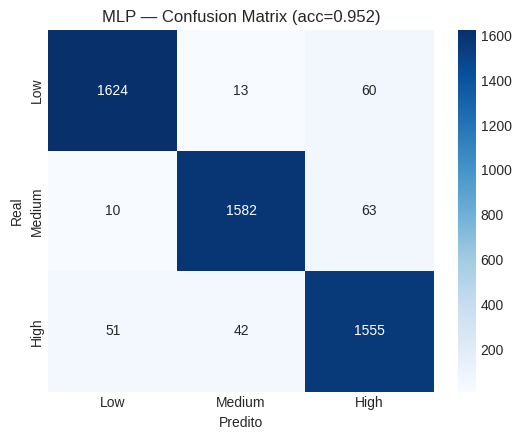

In [12]:
# ============================================================
# 7.3 — CONFUSION MATRIX da MLP
# ============================================================

cm_mlp = confusion_matrix(y_test_tab, y_pred_mlp)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm_mlp, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"],
)
plt.xlabel("Predito"); plt.ylabel("Real")
plt.title(f"MLP — Confusion Matrix (acc={acc_mlp:.3f})")
plt.tight_layout()
plt.show()


## 8️⃣ Persistência da MLP + Scaler + Features

Salvamos tudo em `../modelos/aula05/` com o sufixo padronizado `_qualidade_textil_v1`, seguindo a convenção das outras aulas. O modelo Keras é salvo em **formato `.keras`** (o formato nativo e recomendado do TF 2.x).


In [13]:
# ============================================================
# 8.1 — SALVAR MLP, SCALER E FEATURES
# ============================================================

mlp_path        = os.path.join(MODELOS_DIR, f"mlp_{MLP_VERSION_SUFFIX}.keras")
scaler_mlp_path = os.path.join(MODELOS_DIR, f"scaler_{MLP_VERSION_SUFFIX}.joblib")
feats_mlp_path  = os.path.join(MODELOS_DIR, f"features_{MLP_VERSION_SUFFIX}.joblib")

mlp.save(mlp_path)                        # formato nativo do Keras
joblib.dump(scaler_mlp, scaler_mlp_path)
joblib.dump(feature_cols_mlp, feats_mlp_path)

# Remove o checkpoint temporário usado durante o treino
if os.path.exists(melhor_mlp_path):
    os.remove(melhor_mlp_path)

print("✅ Artefatos da MLP salvos:")
for caminho in [mlp_path, scaler_mlp_path, feats_mlp_path]:
    kb = os.path.getsize(caminho) / 1024
    print(f"   💾 {caminho}  ({kb:.1f} KB)")


✅ Artefatos da MLP salvos:
   💾 ../modelos/aula05/mlp_qualidade_textil_v1.keras  (66.3 KB)
   💾 ../modelos/aula05/scaler_qualidade_textil_v1.joblib  (0.9 KB)
   💾 ../modelos/aula05/features_qualidade_textil_v1.joblib  (0.3 KB)


---

# 🅑 PARTE B — CNN para Detecção de Defeitos em Imagens de Tecido

## 9️⃣ Conceitos — Por que CNN para imagens?

Uma imagem 64×64 em tons de cinza tem **64 × 64 = 4.096 pixels**. Se fôssemos tratar cada pixel como uma feature independente (como faria uma MLP), teríamos uma camada de entrada com 4.096 conexões — **muitos parâmetros** e nenhum entendimento de que pixels vizinhos são relacionados.

**Convoluções** resolvem isso aplicando pequenos **filtros (3×3, 5×5)** que "deslizam" pela imagem e aprendem padrões locais — bordas, texturas, manchas — **reusando os mesmos pesos em todas as posições**. É muito mais eficiente.

### Arquitetura que vamos construir:

```
  Imagem 64×64×1 (grayscale)
         │
         ▼
  ┌───────────────────────────────────────┐
  │ Conv2D(16, 3×3, ReLU) → MaxPool(2×2)  │  ← detecta padrões básicos (bordas)
  └───────────────────────────────────────┘
         │
         ▼
  ┌───────────────────────────────────────┐
  │ Conv2D(32, 3×3, ReLU) → MaxPool(2×2)  │  ← padrões mais complexos (texturas)
  └───────────────────────────────────────┘
         │
         ▼
  ┌───────────────────────────────────────┐
  │ Conv2D(64, 3×3, ReLU) → MaxPool(2×2)  │  ← formas específicas de defeito
  └───────────────────────────────────────┘
         │
         ▼
  Flatten → Dense(64) → Dropout(0.4) → Dense(6, Softmax)
```

**Por que os filtros aumentam (16 → 32 → 64)?** No início, a rede aprende padrões simples (poucos filtros bastam). Conforme descemos, cada posição representa uma região maior e mais abstrata da imagem, então aumentamos o número de filtros para capturar mais variedade.

## 🔟 Carregamento e Subamostragem das Imagens

O dataset `textiledefectdetection` já vem dividido:
- `train64.h5` → 48.000 imagens 64×64 (8.000 por classe)
- `train64.csv` → rótulos das imagens de treino
- `test64.h5` / `test64.csv` → mesma coisa para teste

Para caber numa aula de 3h **sem GPU**, vamos **subamostrar 1.000 imagens por classe** no treino e **400 por classe** no teste (total: 6.000 + 2.400 = 8.400 imagens).

> ⚠️ **Conceito importante:** subamostrar é **apenas uma otimização didática**. Em produção, usaríamos todas as 96.000 imagens com GPU.


In [14]:
# ============================================================
# 10.1 — DOWNLOAD DO DATASET DE IMAGENS (kagglehub)
# ============================================================
# A primeira execução baixa ~3.4 GB. Depois fica em cache.

import kagglehub

caminho_imgs = kagglehub.dataset_download(
    "belkhirnacim/textiledefectdetection"
)
print(f"✅ Dataset disponível em: {caminho_imgs}")

# Listagem dos arquivos relevantes (usaremos os de 64×64)
arquivos = sorted(os.listdir(caminho_imgs))
print("\n📂 Arquivos:")
for a in arquivos:
    tam_mb = os.path.getsize(os.path.join(caminho_imgs, a)) / 1024**2
    print(f"   • {a}  ({tam_mb:.1f} MB)")


100%|██████████| 3.40G/3.40G [00:43<00:00, 84.8MB/s]

Extracting files...


✅ Dataset disponível em: /root/.cache/kagglehub/datasets/belkhirnacim/textiledefectdetection/versions/2

📂 Arquivos:
   • matchingtDATASET_test_32.h5  (140.6 MB)
   • matchingtDATASET_test_64.h5  (562.5 MB)
   • matchingtDATASET_train_32.h5  (281.3 MB)
   • matchingtDATASET_train_64.h5  (1125.0 MB)
   • test32.csv  (1.1 MB)
   • test32.h5  (187.5 MB)
   • test64.csv  (1.1 MB)
   • test64.h5  (750.0 MB)
   • train32.csv  (1.1 MB)
   • train32.h5  (187.5 MB)
   • train64.csv  (1.1 MB)
   • train64.h5  (750.0 MB)


In [15]:
# ============================================================
# 10.2 — LEITURA E SUBAMOSTRAGEM DAS IMAGENS 64x64
# ============================================================
# Usamos uma função utilitária para evitar duplicação de código
# entre o conjunto de treino e o de teste.

N_POR_CLASSE_TREINO = 1000   # 6 classes × 1000 = 6.000 imagens de treino
N_POR_CLASSE_TESTE  = 400    # 6 classes × 400  = 2.400 imagens de teste

def carregar_subset_balanceado(h5_path: str, csv_path: str,
                                n_por_classe: int,
                                seed: int = RANDOM_STATE):
    """Lê o .h5 + .csv e devolve um subset balanceado por classe."""
    rotulos = pd.read_csv(csv_path)
    # Índice aleatório dentro de cada indication_type, pegando N por classe
    idx_por_classe = (
        rotulos.groupby("indication_type")
               .apply(lambda g: g.sample(n=n_por_classe, random_state=seed))
               .reset_index(level=0, drop=True)
               .sort_index()
    )
    posicoes = idx_por_classe.index.to_numpy()   # posições reais dentro do h5

    # Lê apenas as posições selecionadas (h5py permite fancy indexing)
    with h5py.File(h5_path, "r") as f:
        imagens = f["images"][posicoes, :, :, :]   # shape (N, 64, 64, 1)

    labels = idx_por_classe["indication_type"].to_numpy()
    return imagens.astype("float32"), labels


h5_train  = os.path.join(caminho_imgs, "train64.h5")
csv_train = os.path.join(caminho_imgs, "train64.csv")
h5_test   = os.path.join(caminho_imgs, "test64.h5")
csv_test  = os.path.join(caminho_imgs, "test64.csv")

print("📥 Carregando subset de TREINO...")
X_img_train, y_img_train = carregar_subset_balanceado(
    h5_train, csv_train, N_POR_CLASSE_TREINO
)
print("📥 Carregando subset de TESTE...")
X_img_test, y_img_test = carregar_subset_balanceado(
    h5_test, csv_test, N_POR_CLASSE_TESTE
)

print(f"\n✅ Imagens carregadas:")
print(f"   🏋️  Treino: {X_img_train.shape}  |  rótulos: {y_img_train.shape}")
print(f"   🧰 Teste:  {X_img_test.shape}   |  rótulos: {y_img_test.shape}")
print(f"\n📐 Intervalo dos pixels: [{X_img_train.min():.3f}, {X_img_train.max():.3f}]")
print(f"📊 Distribuição treino: {pd.Series(y_img_train).value_counts().to_dict()}")


📥 Carregando subset de TREINO...
📥 Carregando subset de TESTE...

✅ Imagens carregadas:
   🏋️  Treino: (6000, 64, 64, 1)  |  rótulos: (6000,)
   🧰 Teste:  (2400, 64, 64, 1)   |  rótulos: (2400,)

📐 Intervalo dos pixels: [0.031, 0.992]
📊 Distribuição treino: {'good': 1000, 'color': 1000, 'cut': 1000, 'hole': 1000, 'metal_contamination': 1000, 'thread': 1000}


In [16]:
# ============================================================
# 10.3 — NORMALIZAÇÃO DE PIXELS + ENCODE DOS RÓTULOS
# ============================================================
# 1) Pixels do h5 vêm em [0, 1] (já normalizados pela fonte). Garantimos
#    isso com um simples .clip() + checagem.
# 2) Os rótulos são strings ('good', 'color', ...) -> LabelEncoder -> 0..5
# 3) Depois one-hot para casar com softmax.

# Normalização defensiva: garantimos [0, 1]
if X_img_train.max() > 1.5:
    # Se o dataset viesse em 0..255, dividiríamos por 255 aqui
    X_img_train /= 255.0
    X_img_test  /= 255.0

# Encode das classes (mantém a ordem alfabética: color, cut, good, hole, ...)
label_encoder_cnn = LabelEncoder()
y_img_train_enc = label_encoder_cnn.fit_transform(y_img_train)
y_img_test_enc  = label_encoder_cnn.transform(y_img_test)

CLASSES_CNN   = list(label_encoder_cnn.classes_)
N_CLASSES_CNN = len(CLASSES_CNN)

# One-hot
y_img_train_oh = keras.utils.to_categorical(y_img_train_enc, N_CLASSES_CNN)
y_img_test_oh  = keras.utils.to_categorical(y_img_test_enc,  N_CLASSES_CNN)

print(f"✅ {N_CLASSES_CNN} classes de defeitos:")
for i, c in enumerate(CLASSES_CNN):
    print(f"   {i} → {c}")
print(f"\n📐 X_img_train: {X_img_train.shape}  |  y_oh: {y_img_train_oh.shape}")


✅ 6 classes de defeitos:
   0 → color
   1 → cut
   2 → good
   3 → hole
   4 → metal_contamination
   5 → thread

📐 X_img_train: (6000, 64, 64, 1)  |  y_oh: (6000, 6)


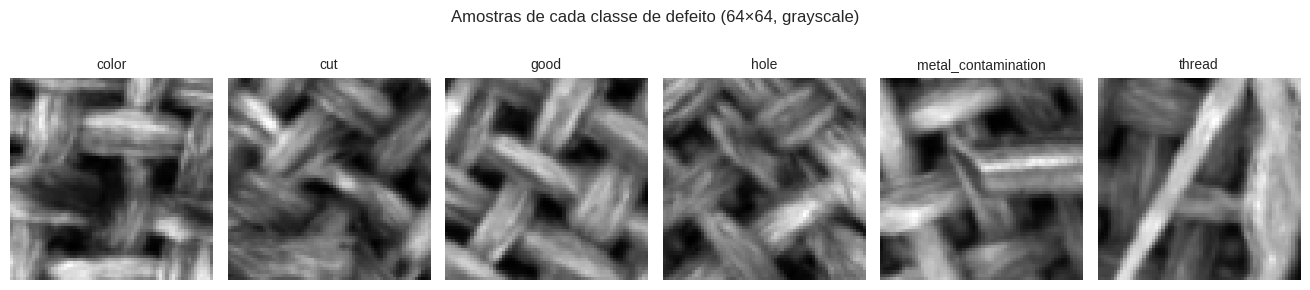

In [17]:
# ============================================================
# 10.4 — VISUALIZAR UMA AMOSTRA DE CADA CLASSE
# ============================================================
# Ver as imagens ajuda a desenvolver intuição antes de treinar.

fig, axes = plt.subplots(1, N_CLASSES_CNN, figsize=(2.2 * N_CLASSES_CNN, 2.8))
for i, classe in enumerate(CLASSES_CNN):
    # Pega a primeira imagem da classe no subset de treino
    idx = np.where(y_img_train == classe)[0][0]
    axes[i].imshow(X_img_train[idx, :, :, 0], cmap="gray")
    axes[i].set_title(classe, fontsize=10)
    axes[i].axis("off")
plt.suptitle("Amostras de cada classe de defeito (64×64, grayscale)", y=1.05)
plt.tight_layout()
plt.show()


In [18]:
# ============================================================
# 10.5 — SEPARAR UM PEDAÇO DO TREINO COMO VALIDAÇÃO
# ============================================================
# Usamos o conjunto de teste só no final. Aqui separamos 15% do treino
# para que o EarlyStopping monitore val_loss durante o treino.

X_img_train, X_img_val, y_img_train_oh, y_img_val_oh = train_test_split(
    X_img_train, y_img_train_oh,
    test_size=0.15,
    stratify=y_img_train_oh.argmax(axis=1),
    random_state=RANDOM_STATE,
)

# Atualiza também as versões codificadas (úteis no classification_report)
y_img_train_enc = y_img_train_oh.argmax(axis=1)
y_img_val_enc   = y_img_val_oh.argmax(axis=1)

print(f"🏋️  CNN — treino:    {X_img_train.shape}  |  y: {y_img_train_oh.shape}")
print(f"🧪 CNN — validação: {X_img_val.shape}    |  y: {y_img_val_oh.shape}")
print(f"🧰 CNN — teste:     {X_img_test.shape}   |  y: {y_img_test_oh.shape}")


🏋️  CNN — treino:    (5100, 64, 64, 1)  |  y: (5100, 6)
🧪 CNN — validação: (900, 64, 64, 1)    |  y: (900, 6)
🧰 CNN — teste:     (2400, 64, 64, 1)   |  y: (2400, 6)


## 1️⃣1️⃣ Construção e Treinamento da CNN

Construímos a arquitetura mostrada no diagrama (3 blocos `Conv → Pool` seguidos por `Flatten → Dense → Dropout → Saída`). Usamos os **mesmos callbacks** da MLP — o padrão é idêntico.


In [19]:
# ============================================================
# 11.1 — DEFINIÇÃO DA ARQUITETURA DA CNN
# ============================================================

def criar_cnn(input_shape: tuple, n_classes: int) -> keras.Model:
    """CNN pequena: 3 blocos Conv+Pool + Dense final."""
    modelo = keras.Sequential(
        [
            layers.Input(shape=input_shape, name="entrada_imagem"),

            # Bloco 1: extrai bordas e padrões simples
            layers.Conv2D(16, (3, 3), activation="relu", padding="same", name="conv1"),
            layers.MaxPooling2D((2, 2), name="pool1"),

            # Bloco 2: padrões de textura
            layers.Conv2D(32, (3, 3), activation="relu", padding="same", name="conv2"),
            layers.MaxPooling2D((2, 2), name="pool2"),

            # Bloco 3: formas específicas de defeito
            layers.Conv2D(64, (3, 3), activation="relu", padding="same", name="conv3"),
            layers.MaxPooling2D((2, 2), name="pool3"),

            # Cabeça de classificação
            layers.Flatten(name="flatten"),
            layers.Dense(64, activation="relu", name="dense1"),
            layers.Dropout(0.4, name="dropout"),
            layers.Dense(n_classes, activation="softmax", name="saida"),
        ],
        name="cnn_defeitos_textil",
    )
    modelo.compile(
        loss="categorical_crossentropy",
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        metrics=["accuracy"],
    )
    return modelo


cnn = criar_cnn(input_shape=X_img_train.shape[1:], n_classes=N_CLASSES_CNN)
cnn.summary()


Model: "cnn_defeitos_textil"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 64, 64, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 285,894 (1.09 MB)

 Trainable params: 285,894 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# ============================================================
# 11.2 — TREINO DA CNN (mesmos callbacks da MLP)
# ============================================================

melhor_cnn_path = os.path.join(MODELOS_DIR, f"_checkpoint_cnn_{CNN_VERSION_SUFFIX}.keras")

callbacks_cnn = [
    EarlyStopping(monitor="val_loss", patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint(filepath=melhor_cnn_path, monitor="val_loss",
                    save_best_only=True, verbose=0),
]

with mlflow.start_run(run_name="cnn_defeitos_textil_v1") as run_cnn:
    historico_cnn = cnn.fit(
        X_img_train, y_img_train_oh,
        validation_data=(X_img_val, y_img_val_oh),
        epochs=15,          # com subsample, 15 já basta com EarlyStopping
        batch_size=64,
        callbacks=callbacks_cnn,
        verbose=2,
    )
    run_id_cnn = run_cnn.info.run_id

print(f"\n✅ CNN treinada. run_id = {run_id_cnn}")
print(f"📊 Epochs executadas: {len(historico_cnn.history['loss'])}")


Epoch 1/15


80/80 - 24s - 302ms/step - accuracy: 0.2282 - loss: 1.7276 - val_accuracy: 0.3056 - val_loss: 1.4958 - learning_rate: 0.0010
Epoch 2/15


80/80 - 41s - 508ms/step - accuracy: 0.3569 - loss: 1.4436 - val_accuracy: 0.4178 - val_loss: 1.3066 - learning_rate: 0.0010
Epoch 3/15


80/80 - 41s - 512ms/step - accuracy: 0.4343 - loss: 1.3459 - val_accuracy: 0.4956 - val_loss: 1.2210 - learning_rate: 0.0010
Epoch 4/15


80/80 - 22s - 270ms/step - accuracy: 0.4924 - loss: 1.2330 - val_accuracy: 0.5444 - val_loss: 1.1539 - learning_rate: 0.0010
Epoch 5/15


...

80/80 - 22s - 270ms/step - accuracy: 0.5716 - loss: 1.0840 - val_accuracy: 0.6022 - val_loss: 1.0112 - learning_rate: 0.0010
Epoch 7/15
80/80 - 20s - 249ms/step - accuracy: 0.5812 - loss: 1.0673 - val_accuracy: 0.5689 - val_loss: 1.0489 - learning_rate: 0.0010
Epoch 8/15

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
80/80 - 21s - 267ms/step - accuracy: 0.5961 - loss: 1.0189 - val_accuracy: 0.5722 - val_loss: 1.0563 - learning_rate: 0.0010
Epoch 9/15


80/80 - 20s - 255ms/step - accuracy: 0.6122 - loss: 0.9859 - val_accuracy: 0.6089 - val_loss: 0.9635 - learning_rate: 5.0000e-04
Epoch 10/15


80/80 - 22s - 271ms/step - accuracy: 0.6278 - loss: 0.9437 - val_accuracy: 0.6122 - val_loss: 0.9514 - learning_rate: 5.0000e-04
Epoch 11/15


80/80 - 40s - 496ms/step - accuracy: 0.6453 - loss: 0.9239 - val_accuracy: 0.6200 - val_loss: 0.9325 - learning_rate: 5.0000e-04
Epoch 12/15
80/80 - 32s - 398ms/step - accuracy: 0.6455 - loss: 0.9026 - val_accuracy: 0.6111 - val_loss: 0.9489 - learning_rate: 5.0000e-04
Epoch 13/15

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
80/80 - 22s - 271ms/step - accuracy: 0.6535 - loss: 0.8831 - val_accuracy: 0.6156 - val_loss: 0.9808 - learning_rate: 5.0000e-04
Epoch 14/15


80/80 - 21s - 258ms/step - accuracy: 0.6567 - loss: 0.8665 - val_accuracy: 0.6333 - val_loss: 0.9179 - learning_rate: 2.5000e-04
Epoch 15/15
80/80 - 22s - 272ms/step - accuracy: 0.6739 - loss: 0.8409 - val_accuracy: 0.6267 - val_loss: 0.9293 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 14.

✅ CNN treinada. run_id = 9327ea7082c24fb89e8d95290f3fbb65
📊 Epochs executadas: 15


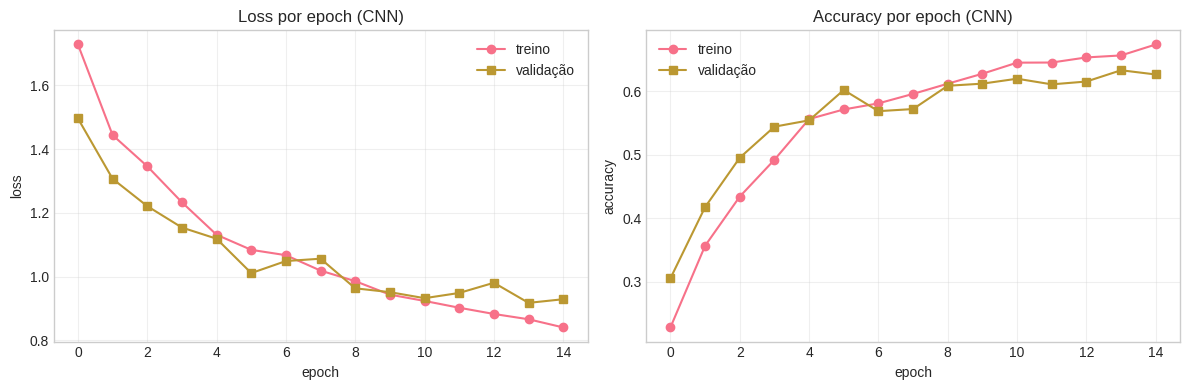

In [21]:
# ============================================================
# 11.3 — CURVAS DE TREINO DA CNN
# ============================================================

hist_c = historico_cnn.history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_c["loss"],     label="treino",    marker="o")
axes[0].plot(hist_c["val_loss"], label="validação", marker="s")
axes[0].set_title("Loss por epoch (CNN)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_c["accuracy"],     label="treino",    marker="o")
axes[1].plot(hist_c["val_accuracy"], label="validação", marker="s")
axes[1].set_title("Accuracy por epoch (CNN)")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 1️⃣2️⃣ Avaliação da CNN no Teste

Avaliamos a CNN nas **2.400 imagens de teste** (400 por classe). Relatamos:

- **Accuracy e F1 macro** — métricas globais
- **Classification report** — precision/recall por classe
- **Confusion matrix** — para ver QUAIS classes o modelo confunde entre si
- **Grid de predições** — ver na prática acertos e erros


In [22]:
# ============================================================
# 12.1 — MÉTRICAS GLOBAIS DA CNN
# ============================================================

y_pred_cnn_prob = cnn.predict(X_img_test, verbose=0)
y_pred_cnn      = y_pred_cnn_prob.argmax(axis=1)

acc_cnn = accuracy_score(y_img_test_enc, y_pred_cnn)
f1_cnn  = f1_score(y_img_test_enc, y_pred_cnn, average="macro")

print(f"🖼️  CNN — Accuracy (teste): {acc_cnn:.4f}")
print(f"🖼️  CNN — F1 macro (teste): {f1_cnn:.4f}\n")
print("📋 Classification report (CNN):")
print(classification_report(
    y_img_test_enc, y_pred_cnn, target_names=CLASSES_CNN
))


🖼️  CNN — Accuracy (teste): 0.5950
🖼️  CNN — F1 macro (teste): 0.5925

📋 Classification report (CNN):
                     precision    recall  f1-score   support

              color       0.91      0.85      0.88       400
                cut       0.29      0.25      0.27       400
               good       0.55      0.76      0.64       400
               hole       0.36      0.40      0.38       400
metal_contamination       0.86      0.85      0.85       400
             thread       0.65      0.46      0.54       400

           accuracy                           0.59      2400
          macro avg       0.60      0.60      0.59      2400
       weighted avg       0.60      0.59      0.59      2400



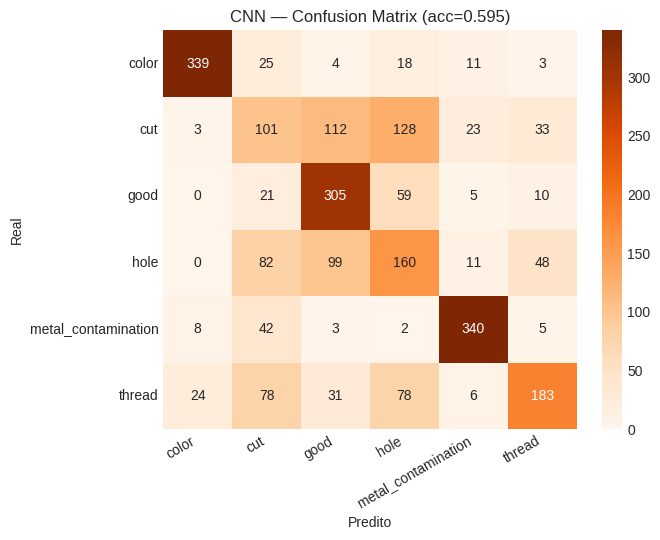

In [23]:
# ============================================================
# 12.2 — CONFUSION MATRIX DA CNN
# ============================================================

cm_cnn = confusion_matrix(y_img_test_enc, y_pred_cnn)
plt.figure(figsize=(7, 5.5))
sns.heatmap(
    cm_cnn, annot=True, fmt="d", cmap="Oranges",
    xticklabels=CLASSES_CNN, yticklabels=CLASSES_CNN,
)
plt.xlabel("Predito"); plt.ylabel("Real")
plt.title(f"CNN — Confusion Matrix (acc={acc_cnn:.3f})")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


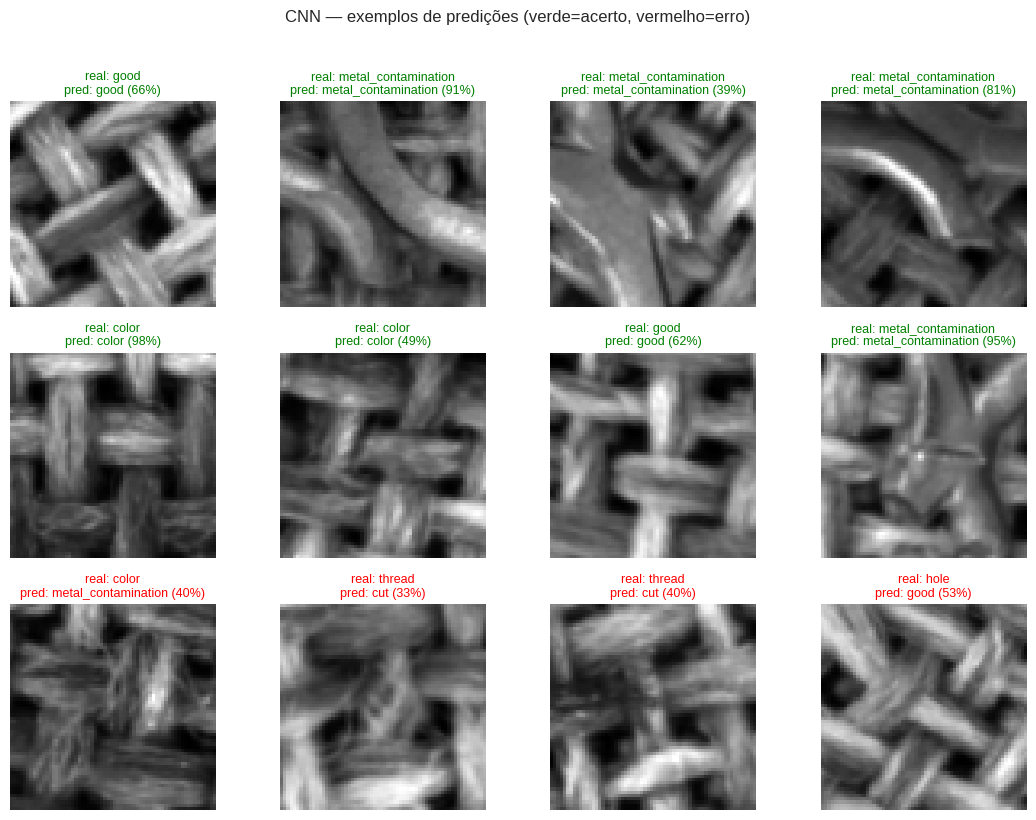

In [24]:
# ============================================================
# 12.3 — GRID DE PREDIÇÕES: ACERTOS E ERROS
# ============================================================
# Mostrar 12 imagens — 8 acertos (verde) e 4 erros (vermelho) — para
# desenvolver intuição visual do que o modelo aprendeu.

rng = np.random.default_rng(RANDOM_STATE)
acertou = np.where(y_pred_cnn == y_img_test_enc)[0]
errou   = np.where(y_pred_cnn != y_img_test_enc)[0]

idx_acertos = rng.choice(acertou, size=min(8, len(acertou)), replace=False)
idx_erros   = rng.choice(errou,   size=min(4, len(errou)),   replace=False)
indices_vis = np.concatenate([idx_acertos, idx_erros])

fig, axes = plt.subplots(3, 4, figsize=(11, 8))
for ax, i in zip(axes.ravel(), indices_vis):
    real = CLASSES_CNN[y_img_test_enc[i]]
    pred = CLASSES_CNN[y_pred_cnn[i]]
    conf = y_pred_cnn_prob[i].max() * 100
    cor  = "green" if real == pred else "red"

    ax.imshow(X_img_test[i, :, :, 0], cmap="gray")
    ax.set_title(f"real: {real}\npred: {pred} ({conf:.0f}%)",
                 fontsize=9, color=cor)
    ax.axis("off")

plt.suptitle("CNN — exemplos de predições (verde=acerto, vermelho=erro)", y=1.02)
plt.tight_layout()
plt.show()


## 1️⃣2️⃣.4 — Interpretabilidade com Grad-CAM 🔍

Até aqui sabemos **quanto** a CNN acerta, mas não **onde** ela está olhando. Na indústria têxtil isso é crítico: o operador da linha precisa confiar no modelo antes de parar um tear por causa de um alerta de defeito.

**Grad-CAM (Gradient-weighted Class Activation Mapping)** resolve isso gerando um *heatmap* que mostra **quais regiões da imagem mais contribuíram** para a rede escolher uma determinada classe.

### Como funciona (intuição rápida)

1. Passamos a imagem pela CNN até a **última camada convolucional** (`conv3`, no nosso caso) — é lá que ficam os mapas de features mais ricos, ainda com informação espacial.
2. Calculamos o **gradiente** da *pontuação da classe predita* em relação a esses mapas de features → descobrimos quais filtros "importaram" para a decisão.
3. Fazemos uma **média ponderada** dos mapas de features usando esses gradientes → produz um heatmap 2D.
4. **Redimensionamos** para 64×64 e sobrepomos à imagem original com transparência.

> 🎯 **Regiões quentes (vermelho/amarelo)** = pixels que mais pesaram na decisão. **Regiões frias (azul)** = a rede praticamente ignorou.

Vamos gerar heatmaps para **1 imagem de cada classe** e comparar lado a lado.


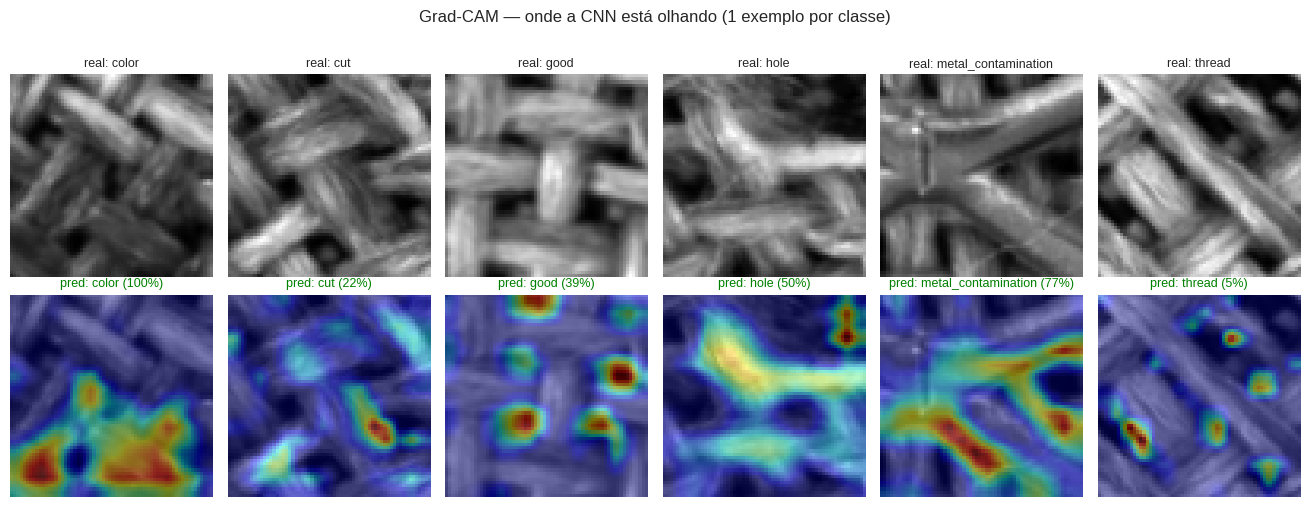

💡 Leitura do mapa:
   🔴 vermelho/amarelo → regiões que PUXARAM a decisão para a classe predita
   🔵 azul escuro     → regiões praticamente ignoradas pela rede


In [25]:
# ============================================================
# 12.4 — GRAD-CAM: ONDE A CNN ESTÁ OLHANDO?
# ============================================================

def construir_grad_model(modelo: keras.Model,
                         nome_camada_conv: str,
                         input_shape: tuple) -> keras.Model:
    """Cria um modelo funcional que devolve (features da conv, saída softmax).

    Reconstruímos manualmente o forward pass porque `Sequential.output`
    não é acessível diretamente no Keras 3.
    """
    inputs = keras.Input(shape=input_shape)
    x = inputs
    features_conv = None
    for camada in modelo.layers:
        x = camada(x)
        if camada.name == nome_camada_conv:
            features_conv = x
    if features_conv is None:
        raise ValueError(f"Camada '{nome_camada_conv}' não encontrada no modelo.")
    return keras.Model(inputs=inputs, outputs=[features_conv, x])


def grad_cam(grad_model: keras.Model,
             imagem: np.ndarray,
             classe_idx: int | None = None) -> tuple[np.ndarray, int, float]:
    """Calcula o heatmap Grad-CAM para uma única imagem.

    Args:
        grad_model:  modelo auxiliar criado por `construir_grad_model`.
        imagem:      array shape (H, W, C). Sem dimensão de batch.
        classe_idx:  classe de interesse; se None, usa a predita.

    Returns:
        heatmap 2D normalizado em [0, 1], classe predita e confiança.
    """
    img_batch = tf.convert_to_tensor(imagem[np.newaxis, ...], dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs, predicoes = grad_model(img_batch, training=False)
        if classe_idx is None:
            classe_idx = int(tf.argmax(predicoes[0]))
        score_classe = predicoes[:, classe_idx]

    # ∂(score da classe) / ∂(mapas de features)
    grads = tape.gradient(score_classe, conv_outputs)[0]          # (h, w, n_filtros)
    conv_outputs = conv_outputs[0]                                # (h, w, n_filtros)

    # Peso de cada filtro = média espacial do seu gradiente
    pesos = tf.reduce_mean(grads, axis=(0, 1))                    # (n_filtros,)

    # Combinação linear dos mapas ponderada pelos gradientes
    heatmap = tf.reduce_sum(conv_outputs * pesos, axis=-1)        # (h, w)
    heatmap = tf.nn.relu(heatmap).numpy()                         # só contribuições positivas

    # Normaliza para [0, 1] (evita divisão por zero)
    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    confianca = float(predicoes[0, classe_idx].numpy())
    return heatmap, classe_idx, confianca


def _redimensiona_heatmap(heatmap: np.ndarray, alvo_hw: tuple[int, int]) -> np.ndarray:
    """Upsample do heatmap (normalmente 8×8) para o tamanho da imagem (64×64)."""
    h = tf.image.resize(heatmap[..., np.newaxis], alvo_hw, method="bilinear")
    return h.numpy().squeeze()


# --- Gera e visualiza Grad-CAM: 1 imagem de cada classe ---
NOME_ULTIMA_CONV = "conv3"   # se mudar a arquitetura, ajuste aqui!
grad_model_cnn = construir_grad_model(
    cnn, NOME_ULTIMA_CONV, input_shape=X_img_test.shape[1:]
)

fig, axes = plt.subplots(2, N_CLASSES_CNN, figsize=(2.2 * N_CLASSES_CNN, 5))

for col, nome_classe in enumerate(CLASSES_CNN):
    classe_alvo = label_encoder_cnn.transform([nome_classe])[0]
    # Pega a 1ª imagem dessa classe no TESTE
    idx = int(np.where(y_img_test_enc == classe_alvo)[0][0])
    img = X_img_test[idx]                                 # (64, 64, 1)

    heatmap, pred_idx, conf = grad_cam(
        grad_model_cnn, img, classe_idx=classe_alvo
    )
    heatmap_64 = _redimensiona_heatmap(heatmap, img.shape[:2])
    pred_nome = CLASSES_CNN[pred_idx]
    cor = "green" if pred_nome == nome_classe else "red"

    # Linha superior: imagem original
    axes[0, col].imshow(img[:, :, 0], cmap="gray")
    axes[0, col].set_title(f"real: {nome_classe}", fontsize=9)
    axes[0, col].axis("off")

    # Linha inferior: imagem + heatmap Grad-CAM
    axes[1, col].imshow(img[:, :, 0], cmap="gray")
    axes[1, col].imshow(heatmap_64, cmap="jet", alpha=0.45)
    axes[1, col].set_title(f"pred: {pred_nome} ({conf*100:.0f}%)",
                           fontsize=9, color=cor)
    axes[1, col].axis("off")

plt.suptitle("Grad-CAM — onde a CNN está olhando (1 exemplo por classe)", y=1.02)
plt.tight_layout()
plt.show()

print("💡 Leitura do mapa:")
print("   🔴 vermelho/amarelo → regiões que PUXARAM a decisão para a classe predita")
print("   🔵 azul escuro     → regiões praticamente ignoradas pela rede")


## 1️⃣3️⃣ Persistência da CNN + LabelEncoder + Ranking Consolidado

Salvamos a CNN em `.keras`, o `LabelEncoder` em `.joblib` (para remapear índices ↔ nomes de classe na inferência) e um CSV com o ranking consolidado de **todos** os modelos desta aula.


In [26]:
# ============================================================
# 13.1 — SALVAR CNN, LABEL ENCODER E CSV DE RESULTADOS
# ============================================================

cnn_path     = os.path.join(MODELOS_DIR, f"cnn_{CNN_VERSION_SUFFIX}.keras")
le_cnn_path  = os.path.join(MODELOS_DIR, f"label_encoder_{CNN_VERSION_SUFFIX}.joblib")

cnn.save(cnn_path)
joblib.dump(label_encoder_cnn, le_cnn_path)

# Limpa checkpoints temporários
if os.path.exists(melhor_cnn_path):
    os.remove(melhor_cnn_path)

# --- CSV consolidado: 3 modelos desta aula lado a lado ---
resultados = pd.DataFrame([
    {"modelo": "MLP (Keras)",  "dataset": "qualidade_textil (tabular)",
     "accuracy": acc_mlp, "f1_macro": f1_mlp},
    {"modelo": "RandomForest", "dataset": "qualidade_textil (tabular)",
     "accuracy": acc_rf,  "f1_macro": f1_rf},
    {"modelo": "CNN (Keras)",  "dataset": "defeitos_textil (imagem 64x64)",
     "accuracy": acc_cnn, "f1_macro": f1_cnn},
]).sort_values("f1_macro", ascending=False).reset_index(drop=True)

resultados_csv = "resultados_aula05.csv"
resultados.to_csv(resultados_csv, index=False)

print("✅ Artefatos finais salvos:")
for caminho in [cnn_path, le_cnn_path]:
    kb = os.path.getsize(caminho) / 1024
    print(f"   💾 {caminho}  ({kb:.1f} KB)")
print(f"   📋 {resultados_csv}")

print(f"\n📁 Conteúdo atual de {MODELOS_DIR}:")
for f in sorted(os.listdir(MODELOS_DIR)):
    tamanho_kb = os.path.getsize(os.path.join(MODELOS_DIR, f)) / 1024
    print(f"   • {f}  ({tamanho_kb:.1f} KB)")

print("\n🏁 Resultados consolidados da Aula 5:")
print(resultados.to_string(index=False))


✅ Artefatos finais salvos:
   💾 ../modelos/aula05/cnn_defeitos_textil_v1.keras  (3396.3 KB)
   💾 ../modelos/aula05/label_encoder_defeitos_textil_v1.joblib  (0.5 KB)
   📋 resultados_aula05.csv

📁 Conteúdo atual de ../modelos/aula05:
   • cnn_defeitos_textil_v1.keras  (3396.3 KB)
   • features_qualidade_textil_v1.joblib  (0.3 KB)
   • label_encoder_defeitos_textil_v1.joblib  (0.5 KB)
   • mlp_qualidade_textil_v1.keras  (66.3 KB)
   • scaler_qualidade_textil_v1.joblib  (0.9 KB)

🏁 Resultados consolidados da Aula 5:
      modelo                        dataset  accuracy  f1_macro
 MLP (Keras)     qualidade_textil (tabular)    0.9522  0.952184
RandomForest     qualidade_textil (tabular)    0.8830  0.883260
 CNN (Keras) defeitos_textil (imagem 64x64)    0.5950  0.592450


## 1️⃣4️⃣ Verificando que os Modelos Salvos Funcionam

Rápida sanity check: recarregamos **do disco** cada modelo e scaler e rodamos 1 predição. Isso garante que, nas aulas seguintes (9 e 10), o pipeline de deploy vai funcionar.


In [27]:
# ============================================================
# 14.1 — RECARREGAR E PREDIZER (smoke test)
# ============================================================

# --- MLP ---
mlp_carregada     = keras.models.load_model(mlp_path)
scaler_carregado  = joblib.load(scaler_mlp_path)
feats_carregadas  = joblib.load(feats_mlp_path)

# Pega 1 amostra crua do teste (não padronizada) para simular uma chamada nova
amostra_mlp = X_test_tab[:1]                 # shape (1, n_features)
amostra_sc  = scaler_carregado.transform(amostra_mlp)
pred_mlp_nv = mlp_carregada.predict(amostra_sc, verbose=0).argmax(axis=1)[0]
nomes_qual  = {0: "Low", 1: "Medium", 2: "High"}

print("🔁 MLP recarregada do disco:")
print(f"   features esperadas: {len(feats_carregadas)}")
print(f"   predição amostra 0: {pred_mlp_nv} ({nomes_qual[pred_mlp_nv]}) "
      f"| real: {y_test_tab[0]} ({nomes_qual[y_test_tab[0]]})")

# --- CNN ---
cnn_carregada = keras.models.load_model(cnn_path)
le_carregado  = joblib.load(le_cnn_path)

amostra_cnn    = X_img_test[:1]              # shape (1, 64, 64, 1)
pred_cnn_nv    = cnn_carregada.predict(amostra_cnn, verbose=0).argmax(axis=1)[0]
pred_cnn_nome  = le_carregado.inverse_transform([pred_cnn_nv])[0]
real_cnn_nome  = le_carregado.inverse_transform([y_img_test_enc[0]])[0]

print("\n🔁 CNN recarregada do disco:")
print(f"   classes: {list(le_carregado.classes_)}")
print(f"   predição amostra 0: {pred_cnn_nome}  | real: {real_cnn_nome}")

print("\n✅ Todos os modelos foram carregados e predizem corretamente!")


🔁 MLP recarregada do disco:
   features esperadas: 15
   predição amostra 0: 1 (Medium) | real: 1 (Medium)

🔁 CNN recarregada do disco:
   classes: ['color', 'cut', 'good', 'hole', 'metal_contamination', 'thread']
   predição amostra 0: good  | real: good

✅ Todos os modelos foram carregados e predizem corretamente!


---

## 📝 Atividade Complementar (Tempo estimado: 1h)

### Objetivo

Desenvolver **intuição sobre arquiteturas** de redes neurais modificando poucos hiperparâmetros e observando o impacto em accuracy, número de parâmetros e tempo de treino.

### Tarefas

**Tarefa 1 — Aumentar a capacidade da MLP**

Modifique a função `criar_mlp` para criar uma **MLP maior**:
- Adicione uma **3ª camada oculta** com 64 neurônios.
- Aumente o dropout da primeira camada de `0.3` para `0.4`.
- Mantenha tudo mais igual.
- Treine a nova MLP (máx. 30 epochs com `EarlyStopping`).
- Compare `test_accuracy` com a MLP original da seção 5. Melhorou, piorou ou ficou igual?

**Tarefa 2 — Reduzir a CNN**

Modifique a função `criar_cnn` para criar uma **CNN minimalista**:
- Use apenas **2 blocos `Conv → Pool`** (remova o terceiro).
- Use `8 → 16` filtros (em vez de `16 → 32 → 64`).
- Mantenha a cabeça densa igual.
- Treine por até 10 epochs.
- Compare **accuracy** e **número de parâmetros** (`model.summary()`) com a CNN original. Quantos parâmetros a menos? O F1 caiu muito?

> 💡 **Dica:** use as células-esqueleto abaixo como ponto de partida. Substitua os trechos com `# SEU CÓDIGO AQUI`.


In [ ]:
# ============================================================
# TAREFA 1 — MLP com mais capacidade (3 camadas ocultas)
# ============================================================

d


Model: "mlp_maior"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,363 (28.76 KB)

 Trainable params: 7,363 (28.76 KB)

 Non-trainable params: 0 (0.00 B)


🆚 Comparação MLP original vs MLP maior:
   MLP original: acc=0.9518 | f1=0.9518
   MLP maior:    acc=0.9504 | f1=0.9504
   Δ accuracy: -0.14 pp


In [ ]:
# ============================================================
# TAREFA 2 — CNN minimalista (2 blocos, menos filtros)
# ============================================================




Model: "cnn_mini"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263,846 (1.01 MB)

 Trainable params: 263,846 (1.01 MB)

 Non-trainable params: 0 (0.00 B)


🆚 Comparação CNN original vs CNN mini:
   CNN original: acc=0.5996 | f1=0.5813 | params=285,894
   CNN mini:     acc=0.5067 | f1=0.4988 | params=263,846
   Redução de parâmetros: 7.7%


### ✍️ Reflexão Final

**Responda abaixo (clique duas vezes nesta célula para editar):**

1. **Para o problema tabular de qualidade, a MLP venceu o RandomForest? Por que você acha que isso acontece?**
   - Resposta: *(escreva aqui)*

2. **Olhando as curvas de treino da MLP e da CNN, você percebe overfitting? Que sinais ajudam a identificar?**
   - Resposta: *(escreva aqui)*

3. **Na Tarefa 1, aumentar a MLP melhorou o resultado? Mais parâmetros sempre ajudam? O que isso tem a ver com a quantidade de dados disponível?**
   - Resposta: *(escreva aqui)*

4. **Na Tarefa 2, quanto a CNN "mini" perdeu em accuracy comparada à original? Em um cenário com celular industrial (pouca memória), qual você usaria? Por quê?**
   - Resposta: *(escreva aqui)*

---

### 🎉 Parabéns!

Você completou a **Aula 5** e agora é capaz de:

- ✅ Explicar a diferença entre **MLP** (tabular) e **CNN** (imagem) e quando usar cada uma
- ✅ Construir uma rede neural com **Keras Sequential** do zero
- ✅ Usar os callbacks clássicos: **EarlyStopping**, **ReduceLROnPlateau**, **ModelCheckpoint**
- ✅ Rastrear treinamentos automaticamente com **MLflow autolog** para TensorFlow
- ✅ Comparar redes neurais com modelos clássicos (RandomForest) em dados tabulares
- ✅ Treinar uma CNN para classificar imagens em 6 classes de defeitos têxteis
- ✅ Versionar modelos Keras (`.keras`) junto com scalers e encoders (`.joblib`)

**Na próxima aula (Aula 6)**, vamos levar redes neurais para o mundo do **NLP**: análise de sentimento em reviews de roupas usando `Embedding → LSTM/GRU → Dense`, comparando com baselines clássicos (TF-IDF + Logistic Regression). 🚀
